# Chronic Kidney Disease — Model Training and Evaluation

This notebook builds a leakage-safe binary classifier for chronic kidney disease using the processed UCI dataset created by the exploration notebook.

The workflow includes stratified splitting, preprocessing inside pipelines, a majority-class baseline, model comparison, validation-only threshold tuning, final untouched-test evaluation, permutation feature importance, and model serialization.

**Target:** `kidney_disease` (`0` = No CKD, `1` = CKD)  
**Source:** UCI Machine Learning Repository — Chronic Kidney Disease (Dataset ID 336)  
**License:** CC BY 4.0  
**Important:** This model is for educational screening only and is not a medical diagnosis.

## 1. Reproducible Training Environment

This step imports the machine-learning, evaluation, visualization, and serialization tools used by the CKD experiment.

A fixed random state is used where appropriate so that data splits and stochastic model behavior can be reproduced. The notebook also defines the project paths for processed data, saved models, and report figures.


In [1]:
from pathlib import Path
import io
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.io import arff


# Configure display and reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore", category=FutureWarning)

# Locate the project root from either the project or notebooks folder
current_folder = Path.cwd()
project_root = current_folder.parent if current_folder.name == "notebooks" else current_folder

data_path = project_root / "data" / "processed" / "kidney_disease_clean.csv"
raw_data_path = project_root / "data" / "raw" / "chronic_kidney_disease_full.arff"
models_folder = project_root / "models"
figures_folder = project_root / "reports" / "figures"

models_folder.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)

model_path = models_folder / "kidney_disease_model.joblib"
evaluation_figure_path = figures_folder / "kidney_final_model_evaluation.png"
importance_figure_path = figures_folder / "kidney_feature_importance.png"

print("Processed dataset path:", data_path)
print("Processed file exists:", data_path.exists())
print("Raw ARFF path:", raw_data_path)
print("Raw ARFF exists:", raw_data_path.exists())

Processed dataset path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\data\processed\kidney_disease_clean.csv
Processed file exists: True
Raw ARFF path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\data\raw\chronic_kidney_disease_full.arff
Raw ARFF exists: True


## 2. Loading and Validating the Modeling Dataset

The processed CKD CSV is loaded when available. If it is missing, the notebook can reconstruct the processed data from the raw ARFF source using the same normalization logic used during exploration.

The target is validated to ensure that it contains only the expected binary classes. Features and target are separated, and the notebook reports dataset dimensions, missingness, duplicates, and class distribution.

This validation prevents silent training on an incorrectly prepared dataset.


In [2]:
# Load the processed CSV when available
if data_path.exists():
    kidney_data = pd.read_csv(data_path)
    print("Loaded the processed CSV created by the exploration notebook.")
else:
    if not raw_data_path.exists():
        raise FileNotFoundError(
            "Place chronic_kidney_disease_full.arff inside data/raw."
        )

    # Normalize whitespace in ARFF data fields before parsing
    # because the official file contains inconsistent spaces and tabs
    raw_text = raw_data_path.read_text(encoding="utf-8", errors="replace")
    normalized_lines = []
    inside_data_section = False
    repaired_rows = 0

    for raw_line in raw_text.splitlines():
        stripped_line = raw_line.strip()

        if stripped_line.lower() == "@data":
            inside_data_section = True
            normalized_lines.append("@data")
        elif inside_data_section and stripped_line and not stripped_line.startswith("%"):
            cleaned_fields = [
                field.strip() if field.strip() else "?"
                for field in raw_line.split(",")
            ]

            # Remove accidental trailing empty fields found in two official rows
            while len(cleaned_fields) > 25 and cleaned_fields[-1] == "?":
                cleaned_fields.pop()
                repaired_rows += 1

            # Repair one official row containing an extra value before appetite
            if (
                len(cleaned_fields) == 26
                and cleaned_fields[-1] in {"ckd", "notckd"}
                and cleaned_fields[21] not in {"good", "poor", "?"}
            ):
                cleaned_fields.pop(21)
                repaired_rows += 1

            if len(cleaned_fields) != 25:
                raise ValueError(
                    f"Unexpected ARFF field count: {len(cleaned_fields)}"
                )

            normalized_lines.append(",".join(cleaned_fields))
        else:
            normalized_lines.append(raw_line)

    normalized_arff = "\n".join(normalized_lines)
    raw_records, _ = arff.loadarff(io.StringIO(normalized_arff))
    kidney_data = pd.DataFrame(raw_records)
    print("Repaired malformed ARFF rows:", repaired_rows)

    # Decode and normalize nominal values returned by the ARFF parser
    for column in kidney_data.select_dtypes(include="object").columns:
        kidney_data[column] = kidney_data[column].map(
            lambda value: (
                value.decode("utf-8", errors="replace")
                if isinstance(value, bytes)
                else value
            )
        )
        kidney_data[column] = kidney_data[column].map(
            lambda value: value.strip().lower() if isinstance(value, str) else value
        )
        kidney_data[column] = kidney_data[column].replace(
            {"?": np.nan, "": np.nan}
        )

    kidney_data = kidney_data.rename(columns={"wc": "wbcc", "rc": "rbcc"})

    raw_numeric_features = [
        "age", "bp", "bgr", "bu", "sc", "sod",
        "pot", "hemo", "pcv", "wbcc", "rbcc",
    ]
    for column in raw_numeric_features:
        kidney_data[column] = pd.to_numeric(kidney_data[column], errors="coerce")

    kidney_data["kidney_disease"] = kidney_data["class"].map(
        {"notckd": 0, "ckd": 1}
    )

    if kidney_data["kidney_disease"].isnull().any():
        invalid_targets = kidney_data.loc[
            kidney_data["kidney_disease"].isnull(), "class"
        ].unique()
        raise ValueError(f"Unexpected target labels: {invalid_targets}")

    kidney_data["kidney_disease"] = kidney_data["kidney_disease"].astype("int8")
    kidney_data = kidney_data.drop(columns=["class"])
    data_path.parent.mkdir(parents=True, exist_ok=True)
    kidney_data.to_csv(data_path, index=False)
    print("Processed CSV was created automatically from the raw ARFF file.")

target_column = "kidney_disease"
if target_column not in kidney_data.columns:
    raise ValueError(f"Required target column is missing: {target_column}")

if kidney_data[target_column].isnull().any():
    raise ValueError("The target contains missing values.")

X = kidney_data.drop(columns=[target_column]).copy()
y = kidney_data[target_column].astype(int).copy()

if set(y.unique()) != {0, 1}:
    raise ValueError(f"Unexpected target values: {sorted(y.unique())}")

print("Full dataset shape:", kidney_data.shape)
print("Feature matrix shape:", X.shape)
print("Total missing feature values:", int(X.isnull().sum().sum()))
print("Duplicated rows:", int(kidney_data.duplicated().sum()))
print("\nTarget distribution (%):")
print(y.value_counts(normalize=True).sort_index().mul(100).round(2))
display(kidney_data.head())

Loaded the processed CSV created by the exploration notebook.
Full dataset shape: (400, 25)
Feature matrix shape: (400, 24)
Total missing feature values: 1013
Duplicated rows: 0

Target distribution (%):
kidney_disease
0    37.5
1    62.5
Name: proportion, dtype: float64


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,kidney_disease
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,1


## Split design

The data is split before fitting imputers or encoders:

- **Development (64%)** — model fitting and five-fold cross-validation.
- **Validation (16%)** — model comparison confirmation and threshold selection.
- **Test (20%)** — final evaluation once, after every modeling decision is fixed.

The split is stratified so each subset preserves the target distribution.

## 3. Creating Development, Validation, and Test Sets

The dataset is split before fitting any imputer, encoder, scaler, or model.

The design reserves:

- A development subset for fitting and cross-validation.
- A validation subset for model confirmation and threshold selection.
- A held-out test subset for final evaluation.

Stratification preserves the class distribution. The notebook also checks whether identical feature profiles overlap across the partitions, which helps identify possible leakage through duplicated observations.


In [3]:
# Create an untouched test set first
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Split the remaining records into development and validation sets
X_development, X_validation, y_development, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

def distribution_percentages(target):
    return target.value_counts(normalize=True).sort_index().mul(100).round(2)

print("Development features shape:", X_development.shape)
print("Validation features shape:", X_validation.shape)
print("Testing features shape:", X_test.shape)
print("\nDevelopment target distribution (%):")
print(distribution_percentages(y_development))
print("\nValidation target distribution (%):")
print(distribution_percentages(y_validation))
print("\nTesting target distribution (%):")
print(distribution_percentages(y_test))

# Verify that exact feature profiles do not cross split boundaries
development_profiles = set(map(tuple, X_development.fillna("<MISSING>").to_numpy()))
validation_profiles = set(map(tuple, X_validation.fillna("<MISSING>").to_numpy()))
test_profiles = set(map(tuple, X_test.fillna("<MISSING>").to_numpy()))

print("\nDevelopment-validation overlap:", len(development_profiles & validation_profiles))
print("Development-test overlap:", len(development_profiles & test_profiles))
print("Validation-test overlap:", len(validation_profiles & test_profiles))

Development features shape: (256, 24)
Validation features shape: (64, 24)
Testing features shape: (80, 24)

Development target distribution (%):
kidney_disease
0    37.5
1    62.5
Name: proportion, dtype: float64

Validation target distribution (%):
kidney_disease
0    37.5
1    62.5
Name: proportion, dtype: float64

Testing target distribution (%):
kidney_disease
0    37.5
1    62.5
Name: proportion, dtype: float64

Development-validation overlap: 0
Development-test overlap: 0
Validation-test overlap: 0


## 4. Pipeline-Based Preprocessing and Candidate Models

Numerical and categorical predictors require different preprocessing.

### Numerical features
Missing values are replaced by the median. Standardization is added for the linear model, while tree-based models use unscaled numerical values.

### Categorical features
Missing categories are replaced by the most frequent value and then converted through one-hot encoding.

Three candidate classifiers are constructed:

- Logistic Regression.
- Random Forest.
- Gradient Boosting.

Because preprocessing is inside each pipeline, all fitted preprocessing parameters are learned only from the training data supplied to that pipeline.


In [4]:
# Identify feature types from the processed dataset
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Total features:", len(numerical_features) + len(categorical_features))

# Create model-specific preprocessing pipelines
numeric_scaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

numeric_unscaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_scaled, numerical_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_unscaled, numerical_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)

candidate_models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", linear_preprocessor),
            (
                "classifier",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=500,
                    min_samples_leaf=2,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "Gradient Boosting": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "classifier",
                GradientBoostingClassifier(
                    n_estimators=150,
                    learning_rate=0.05,
                    max_depth=2,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

Numerical features: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
Categorical features: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
Total features: 24


## 5. Metrics and Majority-Class Baseline

A common evaluation function calculates accuracy, balanced accuracy, precision, recall, F1 score, ROC-AUC, and PR-AUC.

A majority-class predictor is evaluated first. This baseline answers a simple question: **Does the machine-learning model perform meaningfully better than always choosing the most common class?**

For medical-style imbalanced classification, PR-AUC, recall, and balanced accuracy provide information that ordinary accuracy may hide.


In [5]:
# Define reusable binary-classification metrics
def calculate_metrics(y_true, predictions, scores):
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1 Score": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, scores),
        "PR-AUC": average_precision_score(y_true, scores),
    }

# Establish the majority-class baseline on the validation set
majority_class = int(y_development.mode().iloc[0])
baseline_predictions = np.full(len(y_validation), majority_class)
baseline_scores = np.full(len(y_validation), y_development.mean())

baseline_metrics = calculate_metrics(
    y_validation,
    baseline_predictions,
    baseline_scores,
)

results = {
    "Majority Class Baseline": {
        **baseline_metrics,
        "Training Time (s)": np.nan,
    }
}

print("Majority class:", majority_class)
print("Baseline confusion matrix:")
print(confusion_matrix(y_validation, baseline_predictions))
display(pd.DataFrame(results).T.round(4))

Majority class: 1
Baseline confusion matrix:
[[ 0 24]
 [ 0 40]]


,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Training Time (s)
Majority Class Baseline,0.625,0.5,0.625,1.0,0.7692,0.5,0.625,NaN


## 6. Five-Fold Cross-Validation on Development Data

Each candidate pipeline is evaluated with stratified five-fold cross-validation using only the development subset.

Cross-validation estimates:

- Average model performance.
- Variation in performance across folds.
- Stability of the model-selection result.

Balanced accuracy, F1, ROC-AUC, and PR-AUC are tracked. The held-out test set is not involved in this process.


In [6]:
# Estimate model stability with stratified five-fold cross-validation
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

cv_rows = []

for model_name, model_pipeline in candidate_models.items():
    cv_scores = cross_validate(
        model_pipeline,
        X_development,
        y_development,
        cv=cross_validation,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    cv_rows.append(
        {
            "Model": model_name,
            "Balanced Accuracy Mean": cv_scores["test_balanced_accuracy"].mean(),
            "Balanced Accuracy SD": cv_scores["test_balanced_accuracy"].std(),
            "F1 Mean": cv_scores["test_f1"].mean(),
            "F1 SD": cv_scores["test_f1"].std(),
            "ROC-AUC Mean": cv_scores["test_roc_auc"].mean(),
            "ROC-AUC SD": cv_scores["test_roc_auc"].std(),
            "PR-AUC Mean": cv_scores["test_pr_auc"].mean(),
            "PR-AUC SD": cv_scores["test_pr_auc"].std(),
        }
    )

cv_results = pd.DataFrame(cv_rows).set_index("Model")
display(cv_results.round(4))

,Balanced Accuracy Mean,Balanced Accuracy SD,F1 Mean,F1 SD,ROC-AUC Mean,ROC-AUC SD,PR-AUC Mean,PR-AUC SD
Model,,,,,,,,
Logistic Regression,0.9906,0.0125,0.9904,0.0129,1.0000,0.0000,1.0000,0.0000
Random Forest,0.9916,0.0108,0.9937,0.0077,0.9993,0.0013,0.9996,0.0008
Gradient Boosting,0.9916,0.0108,0.9937,0.0077,0.9994,0.0008,0.9996,0.0005


## 7. Candidate Validation Comparison

Each candidate is fitted on the development data and evaluated on the separate validation subset using the default 0.50 threshold.

The resulting metric table, confusion matrices, and training times provide a second view of model behavior after cross-validation.

This step helps confirm whether the cross-validation ranking is consistent with performance on an independent validation partition.


In [7]:
# Fit each candidate on development data and evaluate on validation data
fitted_development_models = {}

for model_name, model_pipeline in candidate_models.items():
    start_time = time.perf_counter()
    fitted_model = clone(model_pipeline)
    fitted_model.fit(X_development, y_development)
    training_time = time.perf_counter() - start_time

    validation_scores = fitted_model.predict_proba(X_validation)[:, 1]
    validation_predictions = (validation_scores >= 0.50).astype(int)

    results[model_name] = {
        **calculate_metrics(
            y_validation,
            validation_predictions,
            validation_scores,
        ),
        "Training Time (s)": training_time,
    }
    fitted_development_models[model_name] = fitted_model

    print(f"{model_name} confusion matrix:")
    print(confusion_matrix(y_validation, validation_predictions))
    print(f"Training time: {training_time:.4f} seconds\n")

validation_results = pd.DataFrame(results).T
display(validation_results.round(4))

Logistic Regression confusion matrix:
[[24  0]
 [ 0 40]]
Training time: 0.3217 seconds

Random Forest confusion matrix:
[[24  0]
 [ 1 39]]
Training time: 1.7928 seconds

Gradient Boosting confusion matrix:
[[24  0]
 [ 1 39]]
Training time: 0.2766 seconds



,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Training Time (s)
Majority Class Baseline,0.6250,0.5000,0.625,1.000,0.7692,0.500,0.6250,NaN
Logistic Regression,1.0000,1.0000,1.000,1.000,1.0000,1.000,1.0000,0.3217
Random Forest,0.9844,0.9875,1.000,0.975,0.9873,1.000,1.0000,1.7928
Gradient Boosting,0.9844,0.9875,1.000,0.975,0.9873,0.999,0.9994,0.2766


## Model and threshold selection

The candidate with the highest development cross-validation PR-AUC is selected. PR-AUC is useful here because it emphasizes performance on the positive CKD class. The validation set then selects a decision threshold that maximizes F1 score; ties are resolved using balanced accuracy and recall. The test set remains untouched.

## 8. Selecting the Model and Decision Threshold

The model with the highest development cross-validation PR-AUC is selected.

Next, multiple decision thresholds are tested using **validation data only**. The preferred threshold maximizes F1 score, with balanced accuracy and recall used as tie-breakers.

The threshold is therefore an empirical operating rule for this classifier. It is not a clinical diagnostic cutoff and should not be interpreted as a medical probability threshold.


In [8]:
# Select the model using development cross-validation only
selected_model_name = cv_results["PR-AUC Mean"].idxmax()
selected_development_model = fitted_development_models[selected_model_name]
validation_scores = selected_development_model.predict_proba(X_validation)[:, 1]

# Search validation thresholds without using the final test set
threshold_rows = []
for threshold in np.linspace(0.05, 0.95, 901):
    predictions = (validation_scores >= threshold).astype(int)
    threshold_rows.append(
        {
            "Threshold": threshold,
            "Balanced Accuracy": balanced_accuracy_score(y_validation, predictions),
            "Precision": precision_score(y_validation, predictions, zero_division=0),
            "Recall": recall_score(y_validation, predictions, zero_division=0),
            "F1 Score": f1_score(y_validation, predictions, zero_division=0),
        }
    )

threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.sort_values(
    ["F1 Score", "Balanced Accuracy", "Recall"],
    ascending=False,
).iloc[0]

selected_threshold = float(best_threshold_row["Threshold"])
tuned_validation_predictions = (validation_scores >= selected_threshold).astype(int)
tuned_validation_metrics = calculate_metrics(
    y_validation,
    tuned_validation_predictions,
    validation_scores,
)

print("Selected model:", selected_model_name)
print(f"Selected threshold: {selected_threshold:.3f}")
print("Tuned validation confusion matrix:")
print(confusion_matrix(y_validation, tuned_validation_predictions))
display(
    pd.DataFrame(
        {
            "Selected Model Tuned": {
                **tuned_validation_metrics,
                "Threshold": selected_threshold,
            }
        }
    ).T.round(4)
)

Selected model: Logistic Regression
Selected threshold: 0.091
Tuned validation confusion matrix:
[[24  0]
 [ 0 40]]


,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Threshold
Selected Model Tuned,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.091


## 9. Final Refit and One-Time Test Evaluation

After the model architecture and threshold are fixed, the selected pipeline is refitted using the combined development and validation data.

The untouched test set is then evaluated exactly once.

The output includes:

- Final classification metrics.
- Confusion matrix.
- Training time.
- Detailed classification report.

These values represent the official held-out CKD model performance for this dataset.


In [9]:
# Refit the selected pipeline on development plus validation data
X_final_training = pd.concat([X_development, X_validation], axis=0)
y_final_training = pd.concat([y_development, y_validation], axis=0)

final_model = clone(candidate_models[selected_model_name])
start_time = time.perf_counter()
final_model.fit(X_final_training, y_final_training)
final_training_time = time.perf_counter() - start_time

# Evaluate exactly once on the untouched test set
test_scores = final_model.predict_proba(X_test)[:, 1]
test_predictions = (test_scores >= selected_threshold).astype(int)
test_metrics = calculate_metrics(y_test, test_predictions, test_scores)
test_confusion_matrix = confusion_matrix(y_test, test_predictions)

final_results = pd.DataFrame(
    {
        f"Final Kidney {selected_model_name}": {
            **test_metrics,
            "Threshold": selected_threshold,
            "Training Time (s)": final_training_time,
        }
    }
).T

display(final_results.round(4))
print("Final kidney disease test confusion matrix:")
print(test_confusion_matrix)
print(f"\nFinal training time: {final_training_time:.4f} seconds")
print("\nClassification report:")
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["No CKD", "CKD"],
        digits=4,
    )
)

,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Threshold,Training Time (s)
Final Kidney Logistic Regression,0.975,0.9667,0.9615,1.0,0.9804,1.0,1.0,0.091,0.0942


Final kidney disease test confusion matrix:
[[28  2]
 [ 0 50]]

Final training time: 0.0942 seconds

Classification report:
              precision    recall  f1-score   support

      No CKD     1.0000    0.9333    0.9655        30
         CKD     0.9615    1.0000    0.9804        50

    accuracy                         0.9750        80
   macro avg     0.9808    0.9667    0.9730        80
weighted avg     0.9760    0.9750    0.9748        80



## 10. Final CKD Evaluation Curves

The final performance is visualized using three complementary views:

1. **Confusion Matrix** — counts correct and incorrect classifications.
2. **ROC Curve** — evaluates discrimination across possible thresholds.
3. **Precision-Recall Curve** — emphasizes positive-class retrieval and false-positive trade-offs.

The positive-class prevalence is included as the precision-recall baseline. The complete figure is saved for the technical report.


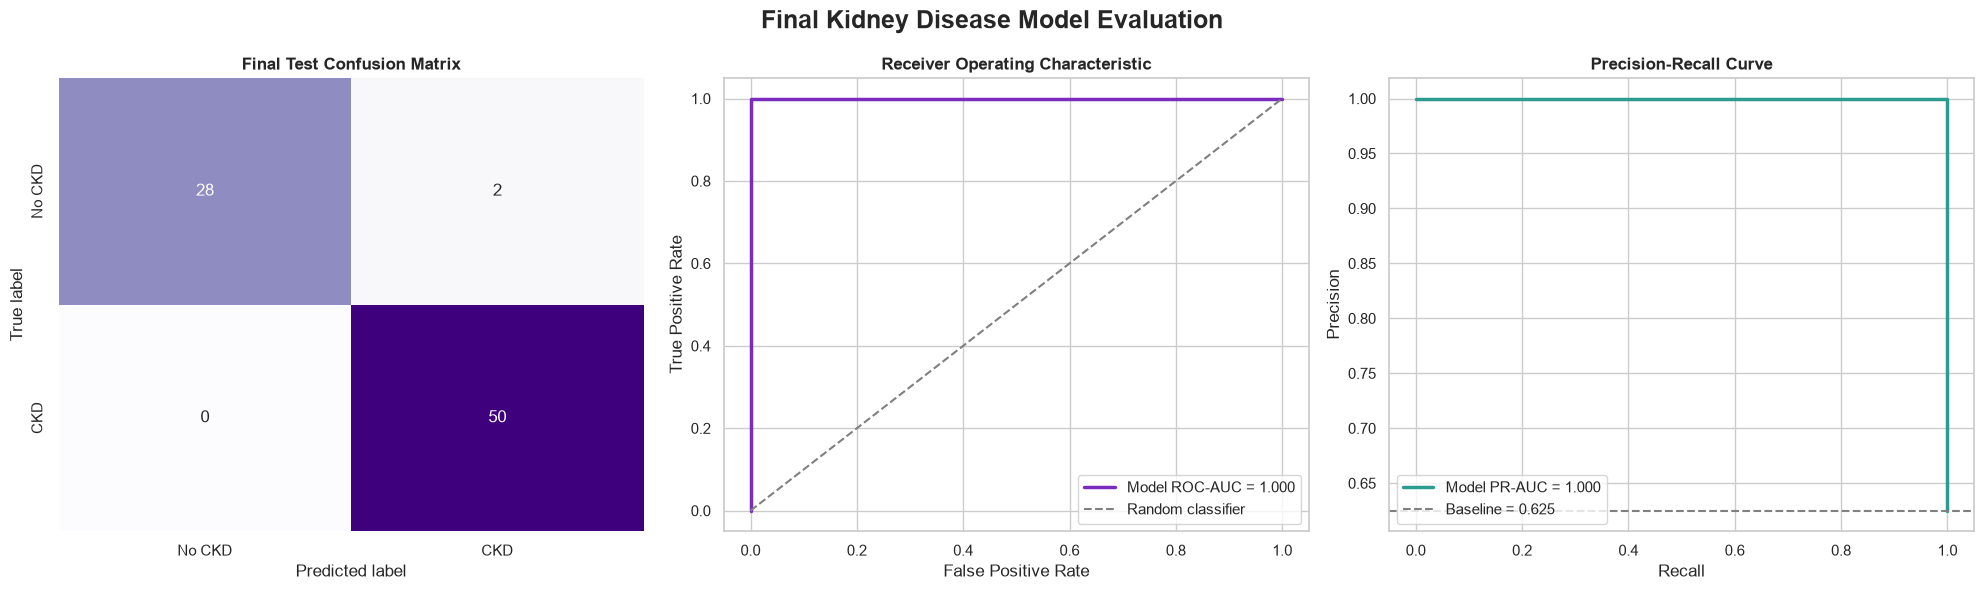

Evaluation figure saved: True
Evaluation figure path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\kidney_final_model_evaluation.png


In [10]:
# Plot the final confusion matrix, ROC curve, and precision-recall curve
false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_scores)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_scores)
positive_prevalence = y_test.mean()

figure, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(
    test_confusion_matrix,
    annot=True,
    fmt=",",
    cmap="Purples",
    cbar=False,
    xticklabels=["No CKD", "CKD"],
    yticklabels=["No CKD", "CKD"],
    ax=axes[0],
)
axes[0].set_title("Final Test Confusion Matrix", fontweight="bold")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

axes[1].plot(
    false_positive_rate,
    true_positive_rate,
    color="#7B2CBF",
    linewidth=2.5,
    label=f"Model ROC-AUC = {test_metrics['ROC-AUC']:.3f}",
)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Random classifier")
axes[1].set_title("Receiver Operating Characteristic", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

axes[2].plot(
    recall_curve,
    precision_curve,
    color="#2A9D8F",
    linewidth=2.5,
    label=f"Model PR-AUC = {test_metrics['PR-AUC']:.3f}",
)
axes[2].axhline(
    positive_prevalence,
    linestyle="--",
    color="gray",
    label=f"Baseline = {positive_prevalence:.3f}",
)
axes[2].set_title("Precision-Recall Curve", fontweight="bold")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend(loc="lower left")

figure.suptitle("Final Kidney Disease Model Evaluation", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.savefig(evaluation_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Evaluation figure saved:", evaluation_figure_path.exists())
print("Evaluation figure path:", evaluation_figure_path)

## 11. CKD Permutation Feature Importance

Permutation importance measures the decrease in average precision after each original feature is randomly shuffled.

A large positive importance means that disturbing that feature harms the model's predictive performance more strongly.

This is a model-interpretation method, not a causal analysis. Results can also be affected by correlated predictors and by the small size of the held-out sample.


,Feature,Importance,Standard Deviation
0,sg,0.0131,0.0044
1,hemo,0.0034,0.0025
2,al,0.0034,0.0020
3,pot,0.0019,0.0027
4,pcv,0.0018,0.0016
5,su,0.0007,0.0009
6,sc,0.0005,0.0009
7,htn,0.0005,0.0006
8,rbcc,0.0004,0.0004
9,bgr,0.0003,0.0004


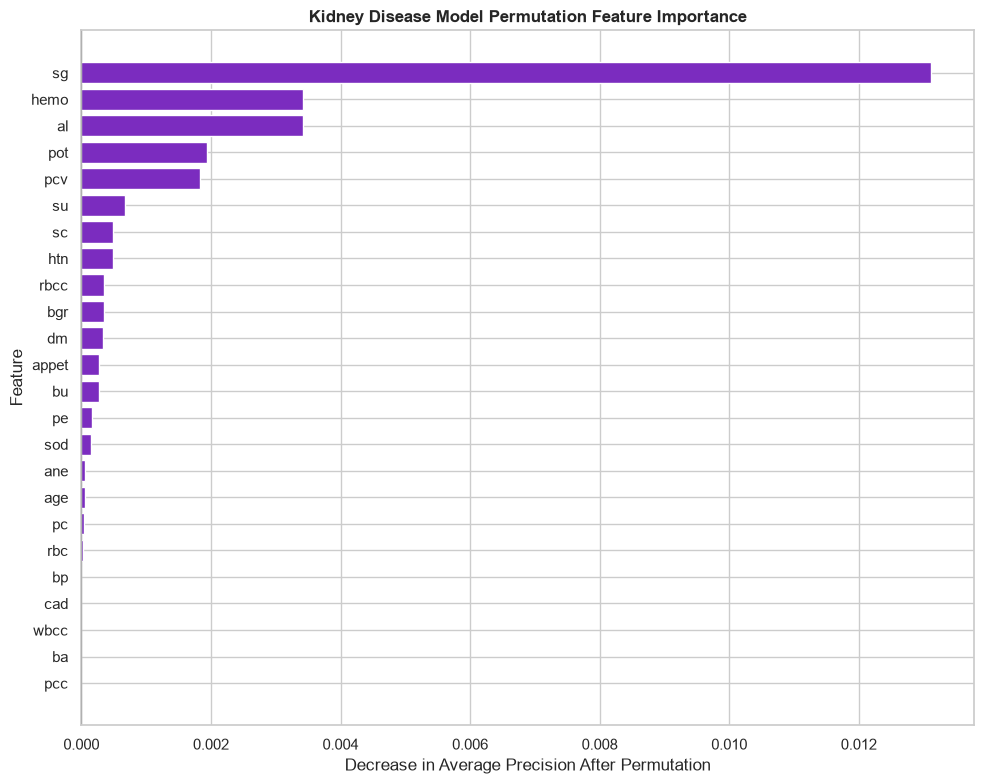

Feature importance figure saved: True
Feature importance figure path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\kidney_feature_importance.png


In [11]:
# Calculate test-set permutation importance using PR-AUC
permutation = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_table = pd.DataFrame(
    {
        "Feature": X_test.columns,
        "Importance": permutation.importances_mean,
        "Standard Deviation": permutation.importances_std,
    }
).sort_values("Importance", ascending=False, ignore_index=True)

display(importance_table.round(4))

plot_table = importance_table.sort_values("Importance", ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(plot_table["Feature"], plot_table["Importance"], color="#7B2CBF")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Kidney Disease Model Permutation Feature Importance", fontweight="bold")
plt.xlabel("Decrease in Average Precision After Permutation")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(importance_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Feature importance figure saved:", importance_figure_path.exists())
print("Feature importance figure path:", importance_figure_path)

## 12. Saving the Complete CKD Inference Artifact

The final artifact includes:

- The complete fitted preprocessing-and-classification pipeline.
- Selected model name.
- Validation-selected threshold.
- Feature lists and feature types.
- Target and class labels.
- Held-out test metrics.
- Dataset attribution and intended-use statement.

The saved file is reloaded and tested on sample records to verify that deployment can reproduce scores and classifications correctly.


In [12]:
# Save the complete inference artifact
model_artifact = {
    "model": final_model,
    "model_name": selected_model_name,
    "threshold": selected_threshold,
    "features": X.columns.tolist(),
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "target": target_column,
    "class_labels": {0: "No CKD", 1: "CKD"},
    "test_metrics": test_metrics,
    "dataset_source": "UCI Chronic Kidney Disease, DOI 10.24432/C5G020",
    "intended_use": "Educational screening only; not a medical diagnosis.",
}

joblib.dump(model_artifact, model_path)

# Reload and verify the saved artifact
loaded_artifact = joblib.load(model_path)
verification_scores = loaded_artifact["model"].predict_proba(X_test.head())[:, 1]
verification_predictions = (
    verification_scores >= loaded_artifact["threshold"]
).astype(int)

print("Kidney model saved successfully:", model_path.exists())
print("Saved model path:", model_path)
print("Saved model name:", loaded_artifact["model_name"])
print("Saved threshold:", loaded_artifact["threshold"])
print("Number of saved features:", len(loaded_artifact["features"]))
print("Verification scores:", np.round(verification_scores, 4))
print("Verification predictions:", verification_predictions)

Kidney model saved successfully: True
Saved model path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\models\kidney_disease_model.joblib
Saved model name: Logistic Regression
Saved threshold: 0.091
Number of saved features: 24
Verification scores: [0.0023 1.     0.9903 0.0031 0.9986]
Verification predictions: [0 1 1 0 1]


## Interpretation and limitations

- The final test metrics estimate generalization only for data similar to this small UCI dataset.
- Missing values are imputed inside the fitted pipeline, preventing validation/test information from influencing preprocessing.
- The tuned score threshold is a model decision rule, not a clinical diagnostic cutoff.
- The displayed model score must not be described as a calibrated clinical probability unless calibration is evaluated separately.
- Permutation importance measures predictive dependence on this test sample; it does not prove medical causation.
- External clinical validation, subgroup analysis, calibration assessment, and prospective testing are required before any real healthcare use.

### Dataset attribution

Rubini, L., Soundarapandian, P., & Eswaran, P. (2015). *Chronic Kidney Disease* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5G020